### 6/23/26 just checking to see if the output is normal

## Background

The goal of this project is to validate diagnostics for calculating numerical mixing through use of a water mass transformation framework. This suspected relationship is outlined in Appendix A of [Global observational estimates of thermohaline transformations by interior ocean mixing](https://doi.org/10.1175/JPO-D-25-0265.1) (Castro et al., 2026). 

Note that a general equation for the diascalar material transformation for a process $P$ for a water mass $\mathcal{M}$ defined to be all tracer $\lambda$ values greater than $\tilde \lambda$. The convergence of a flux $\mathcal{F} = \nabla \cdot \mathbf{F}$.

$$
    \mathcal{G}_{\ge}^{\text{(P)}} = \int_{\mathcal{A_R}(\tilde\lambda, t)} - \frac{\rho}{\vert \nabla \lambda \vert} \mathcal{F} \, \text{d}S = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} -\rho \mathcal{F} \,\text{d} V\right] \tag{1}
$$

And the subsequent diascalar material transformation demonstrating a relationship between mixing calculated as a convergence of a diffusive flux and mixing calculated as tracer variance decay is

*tbh, idk if this is the equation they use, but this is the equation I derived in my advancement proposal*
$$
\begin{equation}
\mathcal{G}^{\text{(phy)}} = \underbrace{\int_{\mathcal{A_R}(\tilde \lambda, t)} - \frac{\rho}{\vert \nabla \lambda \vert} \left(- \nabla \cdot \left(-\kappa_{phy} \nabla \lambda\right)\right) \, \text{d}S}_{\text{mixing as conv. of diff. flux}} = \underbrace{-\frac{1}{2} \frac{\partial^2}{\partial \tilde\lambda^2}\left[ \int_{\Omega(\tilde\lambda ,t)} \rho \left( 2 \kappa_{phy} \vert\vert \nabla \lambda \vert\vert^2\right) \, \text{d}V\right]}_{\text{mixing as var. decay}} 
\tag{2}
\end{equation}
$$ 


While Castro et al. describes a relationship between the convergence of a diffusive tracer flux and tracer variance decay for *phyiscal* mixing, we propose to look at *numerical* mixing through a similar framework. This relationship would look very similar to Equation 2, but our we would instead be solving for the term $\mathcal{G}^{\text{(num)}}$ and the diffusivities would be $\kappa_{num}$ rather than $\kappa_{phy}$. 

### Mixing as convergence of a diffusive flux
We quickly run into a problem, which is that $\kappa_{num}$ is unknown when calculating the nuemrical mixing as the convergence of a diffusive flux. Recall that $\kappa_{phy}$ comes from a prescribed background diffusivity. In which case, we need a different way to calculate $\mathcal{G}^{\text{(num)}}$. We propose to do so using the WMT budget residual.

$$
\begin{align}
    \partial_t{\mathcal{M}} &= \Psi + \mathcal{S} + \mathcal{G^{\text{(BF)}}} + \mathcal{G^{\text{(phy)}}} + \mathcal{G^{\text{(num)}}} \\
    \implies \mathcal{G^{\text{(num)}}} & = \partial_t{\mathcal{M}} - \Psi + \mathcal{S} - \mathcal{G^{\text{(BF)}}} - \mathcal{G^{\text{(phy)}}}
    \tag{3}
\end{align} 
$$

### Mixing as tracer variance decay
We *can*, however, calculate a $\kappa_{num}$ when thinking about numerical mixing through the perspective of tracer variance decay, if we use the Discrete Varaince Decay (DVD) algorithm.
Let 
$$
\begin{equation}
	\chi^{\text{(num)}} = \underbrace{\frac{A\{\left(\lambda_i^n\right)^2\} -\left[A\{\lambda_i^n\}\right]^2}{\Delta t}}_{\text{DVD}} = \underbrace{-2 \kappa_{num}\frac{\left(\lambda_i^n - \lambda_{i-1}^n\right)^2}{(\Delta x)^2}}_{\substack{\text{discretized mixing}\\\text{as variance decay}}} \approx \underbrace{-2 \kappa_{num}\left(\frac{\partial \lambda}{\partial x}\right)^2}_{\substack{\text{continuous mixing}\\\text{as variance decay}}} \tag{4}
\end{equation}
$$

The $\kappa_{num}$ arises out of the mathematical manipulation of the advection operator to get the rest of thet algorithm.
$$
    \kappa_{num} = u\Delta x \left(1 - \frac{u \Delta t}{\Delta x}\right) \tag{5}
$$

The $\chi^{\text{(num)}}$ term is a tendency that can now be written in the WMT framework as 
$$
    \mathcal{G}^{\text{(num)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(num)}} \, \text{d}V\right] \tag{6}
$$

### WMT relationship of numerical mixing as a budget residual and as tracer variance decay.
The following relationship (in terms of the WMT framework) between Equations 2 and 3 then emerges.

$$
\begin{equation}
    \mathcal{G}^{\text{(num)}} = \partial_t{\mathcal{M}} - \Psi + \mathcal{S} - \mathcal{G^{\text{(BF)}}} - \mathcal{G^{\text{(phy)}}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi \, \text{d}V\right] \tag{7}
\end{equation}
$$

*do NOT trust the signs in this argument, it depends on the direction you're integrating, and I'm sure I have several sign errors rn*

In [1]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mosaic
from xgcm import Grid

### Open files & visualize raw data

In [2]:
# filepath = '/pscratch/sd/k/kuyeda/WMT_DVD/bichan/10km/'
# ds_output = xr.open_dataset(filepath + '10km_channel_output.nc')
# ds_dvd = xr.open_dataset(filepath + 'analysis_members/10km_channel_DVD.0001-01-01.nc')
# ds_wmt = xr.open_dataset(filepath + 'analysis_members/10km_channel_WMT_Monthly.0001-01-01.nc')
# mesh = xr.open_dataset(filepath + '10km_channel_init.nc')
# descriptor = mosaic.Descriptor(mesh, use_latlon=False)

In [3]:
filepath = '/pscratch/sd/k/kuyeda/WMT_DVD/bichan/10km/'
ds_output = xr.open_dataset(filepath + '10km_channel_output.nc')
ds_dvd = xr.open_dataset(filepath + 'analysis_members/10km_channel_DVD.0001-01-01.nc')
mesh = xr.open_dataset(filepath + '10km_channel_init.nc')
descriptor = mosaic.Descriptor(mesh, use_latlon=False)

# format ds_dvd so that it includes a time=0 index (otherwise missing first time step)
ds_dvd = xr.concat([ds_dvd.isel(Time=0), ds_dvd],dim='Time')
ds_dvd["xtime"][0]= np.array(b"0001-01-01_00:00:00", dtype="|S64")

ds_dvd['xtime'] = ds_dvd.xtime.assign_attrs(description='time=0 data is copy of time=1')

# interpolate the DVD vertical physical mixing onto nVertLevels
grid_dvd = Grid(ds_dvd, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                        periodic = False, 
                        autoparse_metadata=False)
ds_dvd['chiPhyVerTemp_center'] = grid_dvd.interp(ds_dvd.chiPhyVerTemp, 'Z' ,boundary = 'extend')
ds_dvd['chiPhyVerSalt_center'] = grid_dvd.interp(ds_dvd.chiPhyVerSalt, 'Z', boundary = 'extend')

# merge datasets
ds_output = xr.merge([ds_dvd, ds_output])

# set time index
time_idx = 115

In [4]:
for i in ds_output.data_vars:
    if 'Mix' in i:
        print(i)

temperatureVertMixTendency
salinityVertMixTendency
temperatureHorMixTendency
salinityHorMixTendency


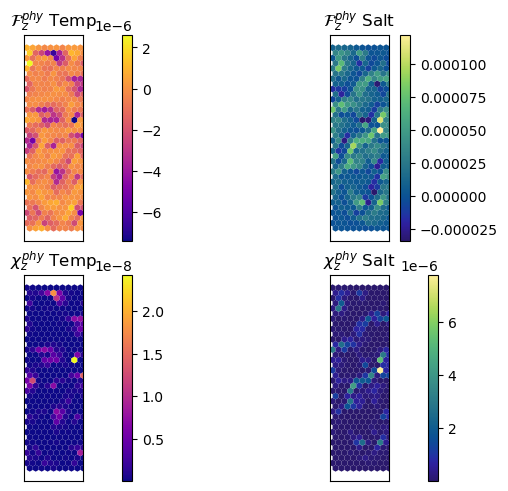

In [5]:
# comparison of mixing
fig,ax = plt.subplots(nrows=2, ncols = 2, constrained_layout=True)

# calculated as convergence of diffusive flux
a = mosaic.polypcolor(ax[0,0],descriptor, ds_output.temperatureVertMixTendency.isel(Time=time_idx, nVertLevels=0), cmap='plasma')
b = mosaic.polypcolor(ax[0,1],descriptor, ds_output.salinityVertMixTendency.isel(Time=time_idx, nVertLevels=0),cmap='cmo.haline')
ax[0,0].set_title(r'$\mathcal{F}^{phy}_{z}$ Temp')
ax[0,1].set_title(r'$\mathcal{F}^{phy}_{z}$ Salt')

# calculated as tracer variance decay
c = mosaic.polypcolor(ax[1,0],descriptor, ds_dvd.chiPhyVerTemp_center.isel(Time=time_idx, nVertLevels=0), cmap='plasma')
d = mosaic.polypcolor(ax[1,1],descriptor, ds_dvd.chiPhyVerSalt_center.isel(Time=time_idx, nVertLevels=0), cmap='cmo.haline')
ax[1,0].set_title(r'$\chi_z^{phy}$ Temp')
ax[1,1].set_title(r'$\chi_z^{phy}$ Salt')

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].set_aspect(1.0)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

fig.colorbar(a, ax = ax[0,0])
fig.colorbar(b, ax = ax[0,1])
fig.colorbar(c, ax = ax[1,0])
fig.colorbar(d, ax = ax[1,1])

## Explanation of data


|Dataset Name|Description|
|--| --|
|`ds_output` | standard output variables (T, S, velo)|
|`ds_dvd` | $\chi^{\text{(phy)}}$ and $\chi^{\text{(num)}}$ from DVD alg.|
|`ds_output` | $\mathcal{F} \,; [^\circ C s^{-1}]$ ; conv. of diff. flux |
|`mesh` | grid variables (cellsOnEdge, etc) |

>- Simulations were run with a linear equation of state such that $\rho_0 = 1027 \, kg/m^3$ $\leftarrow$ CHECK THIS 
>- No prescribed horizontal mixing $\kappa_{phy,x} = 0$, so we expect `TracerHorMixTendency` to be 0 (`ds_output` dataset).
>- Vertical mixing is prescribed using KPP where the background diffusivity is $\kappa_{phy,z} = 10e-5 \, m^2s^{-1}$.
>- The background viscosity is set to $\nu = 10e-4 \, m^2 s^{-1}$.
>- Only wind stress forcing is prescribed.
>- The `TracerSurfaceFluxTendency` in the `ds_output` dataset is 0 because we do not have any boundary forcing that would introduce tracers at the surface.

The $\mathcal{F}$ and $\chi$ outputs require that we calculate $\mathcal{G}^{\text{(phy)}}$ and $\mathcal{G}^{\text{(num)}}$ offline. The following math is necessary.

*Recall that in order to calculate the residual, we need to directly calculate all other terms in the budget*

We need to plug in $\mathcal{F}$ (`TracerVertMixTendency`) into Equation 1.
$$
\begin{equation}
    \mathcal{G}_{\ge}^{\text{(phy)}} = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} \rho \mathcal{F} \,\text{d} V\right] \tag{1}
\end{equation}
$$

We need to plug in $\chi^{\text{(num)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}^{\text{(num)}} = \frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(num)}} \, \text{d}V\right] \tag{6}
\end{equation}
$$

To compare physical mixing calculations, we plug in $\chi^{\text{(phy)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}^{\text{(phy)}} = \frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(phy)}} \, \text{d}V\right] \tag{8}
\end{equation}
$$

## Calculate $\mathcal{G}^{\text{(phy)}}$ from convergence of a diffusive flux

The discretized version of Equation 1 is

$$
\begin{align}
    \mathcal{G}_{\ge}^{\text{(phy)}} = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} \rho \mathcal{F} \,\text{d} V\right] &= \frac{\partial}{\partial \tilde\lambda} \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]  \\
    &=  \left(\left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i+1}} -  \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i}}\right) \times \frac{1}{\tilde\lambda_{i} - \tilde\lambda_{i+1}}
\end{align}
$$
for $(x,y,z) \in \{\lambda \ge \tilde\lambda^\prime\}$.

*Note that we take are looking at $\lambda_i - \lambda_{i+1}$ rather than the other way around. This is because we defined $\mathcal{M}_\ge$ to account for all salinities **greater** than the threshold lambda $\tilde\lambda$. So we are looking from the saltier value to a fresher value (decreasing $\lambda$), rather than a traditional increase.*

*I think this is what also eliminates the negative sign in $\mathcal{G}^{\text{(phy)}}$.*

### Step by step explanation
1. Take the mass tendency (why we multiply by $\rho$) weighted by volume $\left( \text{d}V \right)$ for every grid cell. This is the *integrand*.
2. Regrid from z-coordinates to tracer coordinates
3. For every tracer class, take the sum of the integrand over all grid cells in that tracer class.
4. Calculate the discretized change in integrand (tendency) over change in tracer class.

## Calculate $\mathcal{G}_\chi^{\text{(phy)}}$ from tracer variance decay

To compare physical mixing calculations, we plug in $\chi^{\text{(phy)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}_\chi^{\text{(phy)}} = \frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(phy)}} \, \text{d}V\right] \tag{8}
\end{equation}
$$

### Note these are slightly different signs than the earlier equation box. This is because of how we defined $\mathcal{M}_\ge$, which adds a negative sign, since we are interested in how water is being transformed into masses with $\lambda > \tilde\lambda$... I think (6/30/26)

### Non-generalized functions for calculating $\mathcal{G}^\text{(phy)}$

In [6]:
# write function to calculate G_F_phy
def calculate_G_F_phy(rho_0, mesh, ds_output, target_coord_spacing = 1):
    # calculate the integrand
    dV = (mesh.areaCell * mesh.layerThickness).isel(Time=0)
    integrand = (ds_output.salinityVertMixTendency * rho_0 * dV)
    
    # update ds_output dataset to include integrand dataarray
    ds_output['integrand'] = integrand

    # Remap to salinity coordinates
    # to conservatively remap with xgcm:
    # >- datavariables must sit on cell centers
    # >- must supply cell edges to calculate remap
    # >- datavariable will be transformed onto cell center
    # So we must
    # >- ensure datavariable sits on salinity to begin with
    # >- supply outer (P1) coordinate for the transformation
    # >- transform such that the datavariable sits on salinity and not nVertLevels

    # set up salinity data to be target coords
    # not for this set up, but good practice in case there's topography
    # fill the bottom cell with the same value as the one above it (so it is no longer a nan)
    ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
    
    # calculate target salinity coordinates (salinity_P1)
    # interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
    grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            periodic = False, 
                            autoparse_metadata=False)
    
    ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', boundary = 'extend')
    
    # +2 to ensure that the upper and lower bins have a Gphy = 0
    lower_bound = ds_output.salinity_P1.min() - 2
    upper_bound = ds_output.salinity_P1.max() + 2
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1
    
    # transform integrand (currently sitting on center nVertLevels) to salinity_P1 coordinates
    ds_output_salinity_mix_tendencyZ_transformed = grid_nVertLevels.transform(ds_output.integrand, # data we want to transform (on cell centers)
                                                                           'Z', # axis of transformation
                                                                           target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
                                                                           method = 'conservative', # method
                                                                           target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned
    
    ds_output_salinity_mix_tendencyZ_transformed_ds = ds_output_salinity_mix_tendencyZ_transformed.to_dataset(name='integrand_transformed')
    
    # the transform remapped the datavariable to the CENTER of the cell 
    # rename the salinity_P1 coords to salinity
    ds_output_salinity_mix_tendencyZ_transformed_ds = ds_output_salinity_mix_tendencyZ_transformed_ds.rename({'salinity_P1' : 'salinity'})
    
    # add back the salinity_P1 coordinates
    ds_output_salinity_mix_tendencyZ_transformed_ds = ds_output_salinity_mix_tendencyZ_transformed_ds.assign_coords({'salinity_P1' : target_coords_P1})
    
    # after transforming, our datavariable sits on salinity_P1, but we want to maintain salinity as a coordinate
    # interpolate the salinity_P1 values to get salinity values
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2

    # then calculate the derivative d_integrand
    # create an array
    G_F_phy = []
    
    # taking the difference remaps from salinity coords to salinity_P1 coords
    for i in range(0,len(target_coords_P1) - 2):
        d_tracerMassFlux = ds_output_salinity_mix_tendencyZ_transformed_ds.integrand_transformed[:,:,i] - ds_output_salinity_mix_tendencyZ_transformed_ds.integrand_transformed[:,:,i+1]
        d_tracerMassFlux_dlambda = d_tracerMassFlux / dlambda
        G_F_phy.append(d_tracerMassFlux_dlambda)
    
    # this eliminates the first and last entry in salinity_P1 coords
    salinity_P1_trimmed = target_coords_P1[1:-1]
    G_F_phy_ds = (xr.concat(G_F_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')
    
    # add back salinity_coords
    # after transforming, our datavariable sits on salinity_P1, but we want to maintain salinity as a coordinate
    # interpolate the salinity_P1 values to get salinity values
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1]
    
    G_F_phy_ds = G_F_phy_ds.assign_coords({'salinity' : salinity_trimmed})

    # remap to get onto matching salinity coordinates
    # make a grid that identifies salinity as the vertical coordinates
    grid_salinity = Grid(G_F_phy_ds, coords={'Z': {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                        periodic = False,
                        autoparse_metadata = False)
    
    G_F_phy_ds['G_F_phy_center'] = grid_salinity.interp(G_F_phy_ds.G_F_phy, 'Z', boundary='extend')

    return G_F_phy_ds

In [7]:
# rho_0 = 1026
# target_coord_spacing = 0.25
# # your chi_variable should sit on cell centers
# chi_variable = 'chiPhyVerSalt_center'

def calculate_G_chi_mix(chi_variable, rho_0, mesh, ds_output, target_coord_spacing):
    if 'BR08' in chi_variable:
        mixing_type = 'num'
        print('Calculating G_chi_num')
    if 'Phy' in chi_variable:
        mixing_type = 'phy'
        print('Calculating G_chi_phy')
    
    # calculate the integrand
    dV = mesh.areaCell * mesh.layerThickness.isel(Time=0)
    
    tendency = rho_0 * ds_output[chi_variable] * dV
    
    # +2 to ensure that the upper and lower bins have Gphy = 0
    lower_bound = ds_output.salinity_P1.min() - 2
    upper_bound = ds_output.salinity_P1.max() + 2
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    
    d_lambda = target_coords_P1[0] - target_coords_P1[1] # d_lambda < 0 b/c we are taking the derivative as i --> 0 so i - i+1
    salinity_P1_trimmed = target_coords_P1[1:-1] # finite difference eliminates first and last values of array
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1] # second finite difference eliminates first and last values of array
    
    # transform chi data from nVertLevels coord to salinity coord
    grid = Grid(ds_output, coords = {'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                periodic = False,
                autoparse_metadata = False)
    
    ds_chi_tendency_transformed = grid.transform(tendency, # currently sitting on cell centers
                                                  'Z',
                                                  target_coords_P1, # consersvative remap requires specifying target edge coords
                                                  method = 'conservative',
                                                  target_data = ds_output.salinity_P1)  # corresponding actual coords to be binned in target_coords)
    
    ds_chi_tendency_transformed = ds_chi_tendency_transformed.to_dataset(name = 'tendency_'+ chi_variable)
    
    # transform remapped the datavariable to the CENTER of the cell
    # rename the salinity_P1 coords to salinity
    ds_chi_tendency_transformed = ds_chi_tendency_transformed.rename({'salinity_P1' : 'salinity'})
    
    tendency_variable = 'tendency_' + chi_variable
    
    # calculate the first derivative (d_integrand / d_lambda)
    mixingFlux = []
    
    # take the first deriv (from salinity coords to salinity_P1 coords) with i - i+1
    # requires coords to be ordered as (salinity, nCells, Time)
    for i in range(0,len(target_coords_P1)-2):
        d_mixing = ds_chi_tendency_transformed[tendency_variable][:,:,i] - ds_chi_tendency_transformed[tendency_variable][:,:,i+1]
        d_mixing_d_lambda = d_mixing / d_lambda # mixing per salinity class 
        mixingFlux.append(d_mixing_d_lambda)
    
    # convert mixingFlux to dataarray
    mixingFlux_da = xr.concat(mixingFlux, dim='salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)
    
    # take the second derivative (from salinity_P1 coords back to salinity coords)
    # again, by taking the differrence, you will lose the first and last entries of the salinity coords
    # this derivative calculates the convergence of the mixing flux
    
    G_chi_mix = []
    
    for i in range(0,len(target_coords)-2):
        d_mixingFlux = mixingFlux_da[i,:,:] - mixingFlux_da[i+1,:,:]
        conv_mixingFlux = d_mixingFlux / d_lambda
        G_chi_mix.append(conv_mixingFlux * 0.5) # by definition, G_chi_mix is multiplied by 1/2
    
    # convert G_chi_mix to dataset
    G_chi_mix_ds = (xr.concat(G_chi_mix, dim= 'salinity').assign_coords(salinity = salinity_trimmed)).to_dataset(name='G_chi_' + mixing_type)
    
    # add back the salinity_P1 coordinates
    G_chi_mix_ds = G_chi_mix_ds.assign_coords({'salinity_P1' : salinity_P1_trimmed})

    return G_chi_mix_ds

In [8]:
# wrapper function to perform all calculations
def calculate_G_mix(rho_0, mesh, ds_output, target_coord_spacing = 1):
    G_F_phy_ds = calculate_G_F_phy(rho_0, mesh, ds_output,target_coord_spacing)
    G_chi_phy_ds = calculate_G_chi_mix('chiPhyVerSalt_center',rho_0, mesh, ds_output,target_coord_spacing)
    G_chi_num_ds = calculate_G_chi_mix('chiSpurSaltBR08',rho_0, mesh, ds_output,target_coord_spacing)
    
    # combine the G_phy_ds and G_phy_chi_ds datasets
    G_phy_comp_ds = xr.merge([G_F_phy_ds.G_F_phy.transpose('salinity_P1', 'nCells', 'Time'), 
                              G_F_phy_ds.G_F_phy_center.transpose('salinity', 'nCells', 'Time'), 
                              G_chi_phy_ds,
                              G_chi_num_ds,
                              ds_output.xtime])

    return G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, G_phy_comp_ds

In [9]:
# calculate transformation at every density class
def vertical_cumsum(G_phy_ds, variable, reduce_time_dim_method, time_idx=0):

    if reduce_time_dim_method == 'average':
        G_phy = G_phy_ds[variable].mean(dim='Time').sum(dim='nCells')

    if reduce_time_dim_method == 'isel':
        G_phy = G_phy_ds[variable].isel(Time = time_idx).sum(dim='nCells')
        
    # cumsum from bottom (lowest salinity class) to top (highest salinity class)
    # we need to perform a reverse cumsum because our water mass M is defined to be all values GREATER Than threshold lambda
    # reduce G_phy_ds along several dimensions
    
    rev_G_phy = np.flipud(G_phy)
    cumsum_rev_G_phy = np.cumsum(rev_G_phy)
    # reverse back to match highest salinity value to lowest cumsum value
    cumsum_G_phy = np.flipud(cumsum_rev_G_phy)

    print('reduced time dimension by ', reduce_time_dim_method)
    if reduce_time_dim_method == 'isel':
        print('time_idx = ', time_idx)

    return G_phy, cumsum_G_phy

In [10]:
## figure out at what salinity are the minima and maxima located for G_F_phy and G_chi_phy

def find_min_max_idx(da):
    # max if G_i > G_i+1 and G_i > G_i-1
    maxima_indices = np.where((da[1:-1] > da[:-2]) & (da[1:-1] > da[2:]))[0] + 1
    print('maxima at ', da[maxima_indices])
    
    # min if G_i < G_i+1 and G_i < Gi-1
    minima_indices = np.where((da[1:-1] < da[:-2]) & (da[1:-1] < da[2:]))[0] + 1
    print('minima at ' , da[minima_indices])

    return maxima_indices, minima_indices

-------
--------

In [11]:
rho_0 = 1026

G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, G_phy_comp_ds = calculate_G_mix(rho_0, mesh, ds_output, target_coord_spacing = 1)

Calculating G_chi_phy
Calculating G_chi_num


In [12]:
# remap the salinity tendency into salinity coordinates
grid_output = Grid(ds_output, coords = {'Z' : {'center': 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                    periodic = False,
                    autoparse_metadata = False)


ds_dt = grid_dvd.transform(ds_output.salinityTend,
                           'Z',
                           G_phy_comp_ds.salinity_P1,
                           method = 'conservative',
                           target_data = ds_output.salinity_P1)
ds_dt = ds_dt.to_dataset(name='salinityTend').rename({'salinity_P1' : 'salinity'})

# calculate residual
G_F_num = ds_dt.salinityTend - G_phy_comp_ds.G_F_phy_center

In [13]:
ds_chi_transform = grid_dvd.transform(ds_output.chiSpurSaltBR08,
                                      'Z',
                                      G_phy_comp_ds.salinity_P1,
                                      method = 'conservative',
                                      target_data = ds_output.salinity_P1)
ds_chi_transform = ds_chi_transform.to_dataset(name= 'chi_num').rename({'salinity_P1' : 'salinity'})

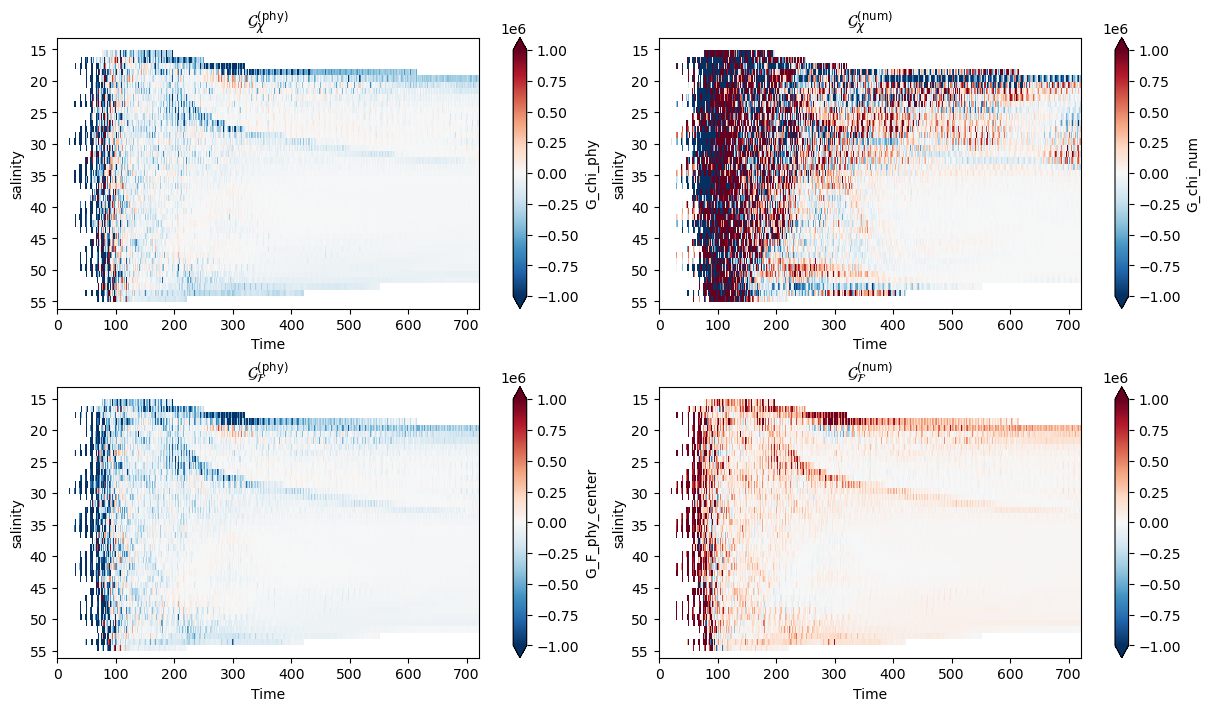

In [14]:
fig, ax = plt.subplots(nrows=2,ncols=2,constrained_layout=True,figsize=(12,7))

G_phy_comp_ds.G_chi_phy.mean(dim='nCells').plot(ax=ax[0,0],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r')
ax[0,0].set_title(r'$\mathcal{G}_\chi^{\text{(phy)}}$')
G_phy_comp_ds.G_chi_num.mean(dim='nCells').plot(ax=ax[0,1],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r')
ax[0,1].set_title(r'$\mathcal{G}_\chi^{\text{(num)}}$')

G_phy_comp_ds.G_F_phy_center.mean(dim='nCells').plot(ax=ax[1,0],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r')
ax[1,0].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
G_F_num.mean(dim='nCells').plot(ax=ax[1,1],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r')
ax[1,1].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$')

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].invert_yaxis()

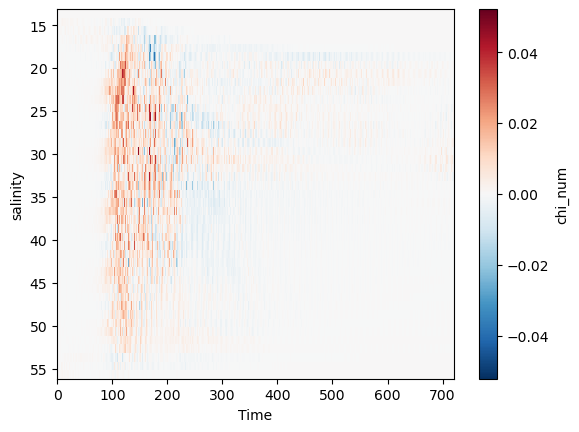

In [15]:
ds_chi_transform.chi_num.sum('nCells').plot(y='salinity')
plt.gca().invert_yaxis()

In [18]:
weighted_avg_salinity = []
dV = (mesh.areaCell * mesh.layerThickness).isel(Time=0)
for i in range(0,len(ds_output.nVertLevels)):
    # calculate the volume-weighted average salinity at each nVertLevel 
    integrand = ds_output.salinity.mean(dim='Time').isel(nVertLevels= slice(0,i)) * dV.isel(nVertLevels = slice(0,i))
    integral = integrand.sum()
    total_volume = (dV.isel(nVertLevels = slice(0,i))).sum()
    average = (integral / total_volume).values
    weighted_avg_salinity.append(average)

weighted_avg_salinity_array = np.array(weighted_avg_salinity)    

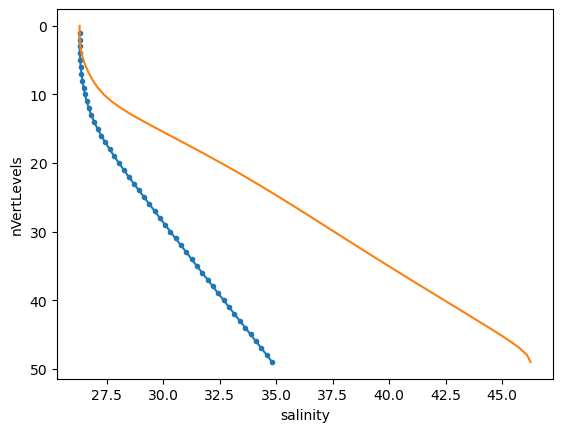

In [19]:
plt.plot(weighted_avg_salinity_array, ds_output.nVertLevels, marker = '.')
ds_output.salinity.mean(dim=['nCells','Time']).plot(y='nVertLevels')
plt.gca().invert_yaxis()

In [20]:
dV_sal = grid_output.transform(
    dV,
    "Z",
    target_coords_P1,
    method="conservative",
    target_data=ds_output.salinity_P1.mean("Time")
)

SdV_sal = grid_output.transform(
    ds_output.salinity.mean("Time") * dV,
    "Z",
    target_coords_P1,
    method="conservative",
    target_data=ds_output.salinity_P1.mean("Time")
)

dV_sal = dV_sal.sum("nCells")
SdV_sal = SdV_sal.sum("nCells")

cum_volume = dV_sal.cumsum("salinity_P1")
cum_SdV = SdV_sal.cumsum("salinity_P1")

weighted_avg_sal_transform = (
    cum_SdV / cum_volume
).to_dataset(name="weighted_avg_sal_transform").rename({'salinity_P1' : 'salinity'})

NameError: name 'target_coords_P1' is not defined

In [21]:
weighted_avg_sal_transform.weighted_avg_sal_transform.plot(marker='.')

NameError: name 'weighted_avg_sal_transform' is not defined

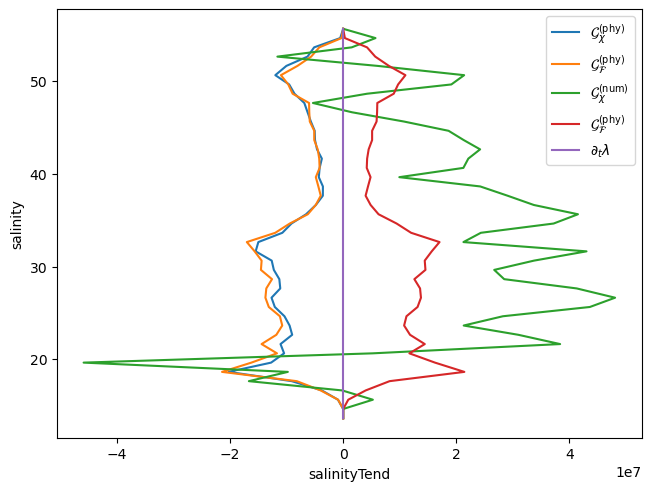

In [22]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)
G_phy_comp_ds.sum('nCells').mean(dim='Time').G_chi_phy.plot(y='salinity',label = r'$\mathcal{G}_\chi^{\text{(phy)}}$')
G_phy_comp_ds.sum('nCells').mean(dim='Time').G_F_phy_center.plot(y='salinity', label = r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
G_phy_comp_ds.sum('nCells').mean(dim='Time').G_chi_num.plot(y='salinity', label = r'$\mathcal{G}_\chi^{\text{(num)}}$')
G_F_num.sum('nCells').mean(dim='Time').plot(y='salinity', label = r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
ds_dt.sum('nCells').mean(dim='Time').salinityTend.plot(y='salinity', label = r'$\partial_t \lambda$')

ax.legend()

In [23]:
G_F_phy_ds, G_chi_phy_ds, G_phy_comp_ds =  calculate_G_phy(1026, mesh,ds_output, ds_dvd, 0.25)

NameError: name 'calculate_G_phy' is not defined

In [28]:
G_F_phy_avg, cumsum_G_F_phy_avg = vertical_cumsum(G_phy_comp_ds, 'G_F_phy_center', 'average')

reduced time dimension by  average


In [29]:
G_F_phy_isel, cumsum_G_F_phy_isel = vertical_cumsum(G_phy_comp_ds, 'G_F_phy_center', 'isel', time_idx)

reduced time dimension by  isel
time_idx =  115


In [30]:
G_chi_phy_avg, cumsum_G_chi_phy_avg = vertical_cumsum(G_phy_comp_ds, 'G_chi_phy', 'average')

reduced time dimension by  average


In [31]:
G_chi_phy_ds0 =  calculate_G_chi_mix('chiPhyVerSalt_center',1026, mesh, ds_output, 0.25)
G_chi_phy_avg0, cumsum_G_chi_phy_avg0 = vertical_cumsum(G_chi_phy_ds0, 'G_chi_phy', 'average')

Calculating G_chi_phy
reduced time dimension by  average


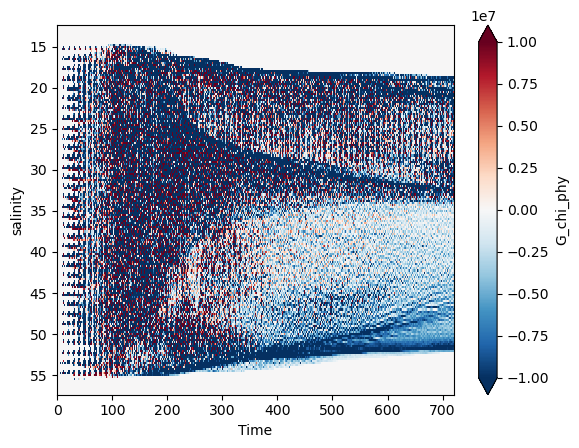

In [32]:
G_chi_phy_ds0.G_chi_phy.sum(dim='nCells').plot(y='salinity',vmin=-1e7,vmax=1e7,cmap='RdBu_r')
plt.gca().invert_yaxis()

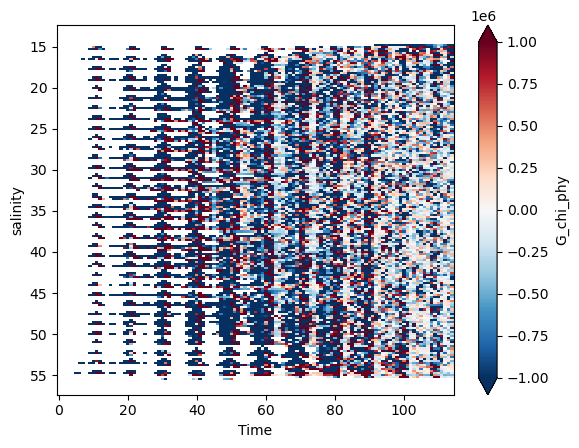

In [33]:
G_chi_phy_ds0.G_chi_phy.isel(Time=slice(0,115)).mean(dim=['nCells']).plot(y='salinity',vmin=-1e6,vmax=1e6, cmap='RdBu_r')
plt.gca().invert_yaxis()

In [34]:
farther_away = G_chi_phy_ds0.G_chi_phy.isel(nCells = slice(280,360))

In [35]:
farther_away.salinity

<xarray.DataArray 'salinity' (salinity: 180)> Size: 1kB
array([12.511759, 12.761759, 13.011759, 13.261759, 13.511759, 13.761759,
       14.011759, 14.261759, 14.511759, 14.761759, 15.011759, 15.261759,
       15.511759, 15.761759, 16.011759, 16.261759, 16.511759, 16.761759,
       17.011759, 17.261759, 17.511759, 17.761759, 18.011759, 18.261759,
       18.511759, 18.761759, 19.011759, 19.261759, 19.511759, 19.761759,
       20.011759, 20.261759, 20.511759, 20.761759, 21.011759, 21.261759,
       21.511759, 21.761759, 22.011759, 22.261759, 22.511759, 22.761759,
       23.011759, 23.261759, 23.511759, 23.761759, 24.011759, 24.261759,
       24.511759, 24.761759, 25.011759, 25.261759, 25.511759, 25.761759,
       26.011759, 26.261759, 26.511759, 26.761759, 27.011759, 27.261759,
       27.511759, 27.761759, 28.011759, 28.261759, 28.511759, 28.761759,
       29.011759, 29.261759, 29.511759, 29.761759, 30.011759, 30.261759,
       30.511759, 30.761759, 31.011759, 31.261759, 31.511759, 31.761759,
       32.011759, 32.261759, 32.511759, 32.761759, 33.011759, 33.261759,
       33.511759, 33.761759, 34.011759, 34.261759, 34.511759, 34.761759,
       35.011759, 35.261759, 35.511759, 35.761759, 36.011759, 36.261759,
       36.511759, 36.761759, 37.011759, 37.261759, 37.511759, 37.761759,
       38.011759, 38.261759, 38.511759, 38.761759, 39.011759, 39.261759,
       39.511759, 39.761759, 40.011759, 40.261759, 40.511759, 40.761759,
       41.011759, 41.261759, 41.511759, 41.761759, 42.011759, 42.261759,
       42.511759, 42.761759, 43.011759, 43.261759, 43.511759, 43.761759,
       44.011759, 44.261759, 44.511759, 44.761759, 45.011759, 45.261759,
       45.511759, 45.761759, 46.011759, 46.261759, 46.511759, 46.761759,
       47.011759, 47.261759, 47.511759, 47.761759, 48.011759, 48.261759,
       48.511759, 48.761759, 49.011759, 49.261759, 49.511759, 49.761759,
       50.011759, 50.261759, 50.511759, 50.761759, 51.011759, 51.261759,
       51.511759, 51.761759, 52.011759, 52.261759, 52.511759, 52.761759,
       53.011759, 53.261759, 53.511759, 53.761759, 54.011759, 54.261759,
       54.511759, 54.761759, 55.011759, 55.261759, 55.511759, 55.761759,
       56.011759, 56.261759, 56.511759, 56.761759, 57.011759, 57.261759])
Coordinates:
  * salinity  (salinity) float64 1kB 12.51 12.76 13.01 ... 56.76 57.01 57.26

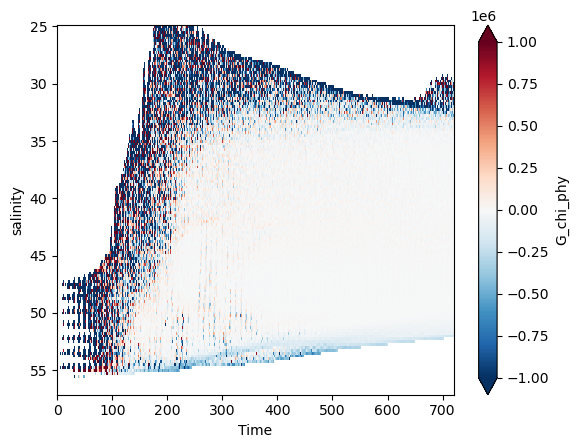

In [36]:
farther_away.isel(salinity=slice(50,-1)).mean(dim='nCells').plot(y='salinity',vmin=-1e6, vmax=1e6,cmap = 'RdBu_r')
plt.gca().invert_yaxis()


In [37]:
ds_output.salinity.min()

<xarray.DataArray 'salinity' ()> Size: 8B
array(14.1367588)

In [38]:
farther_away.salinity

<xarray.DataArray 'salinity' (salinity: 180)> Size: 1kB
array([12.511759, 12.761759, 13.011759, 13.261759, 13.511759, 13.761759,
       14.011759, 14.261759, 14.511759, 14.761759, 15.011759, 15.261759,
       15.511759, 15.761759, 16.011759, 16.261759, 16.511759, 16.761759,
       17.011759, 17.261759, 17.511759, 17.761759, 18.011759, 18.261759,
       18.511759, 18.761759, 19.011759, 19.261759, 19.511759, 19.761759,
       20.011759, 20.261759, 20.511759, 20.761759, 21.011759, 21.261759,
       21.511759, 21.761759, 22.011759, 22.261759, 22.511759, 22.761759,
       23.011759, 23.261759, 23.511759, 23.761759, 24.011759, 24.261759,
       24.511759, 24.761759, 25.011759, 25.261759, 25.511759, 25.761759,
       26.011759, 26.261759, 26.511759, 26.761759, 27.011759, 27.261759,
       27.511759, 27.761759, 28.011759, 28.261759, 28.511759, 28.761759,
       29.011759, 29.261759, 29.511759, 29.761759, 30.011759, 30.261759,
       30.511759, 30.761759, 31.011759, 31.261759, 31.511759, 31.761759,
       32.011759, 32.261759, 32.511759, 32.761759, 33.011759, 33.261759,
       33.511759, 33.761759, 34.011759, 34.261759, 34.511759, 34.761759,
       35.011759, 35.261759, 35.511759, 35.761759, 36.011759, 36.261759,
       36.511759, 36.761759, 37.011759, 37.261759, 37.511759, 37.761759,
       38.011759, 38.261759, 38.511759, 38.761759, 39.011759, 39.261759,
       39.511759, 39.761759, 40.011759, 40.261759, 40.511759, 40.761759,
       41.011759, 41.261759, 41.511759, 41.761759, 42.011759, 42.261759,
       42.511759, 42.761759, 43.011759, 43.261759, 43.511759, 43.761759,
       44.011759, 44.261759, 44.511759, 44.761759, 45.011759, 45.261759,
       45.511759, 45.761759, 46.011759, 46.261759, 46.511759, 46.761759,
       47.011759, 47.261759, 47.511759, 47.761759, 48.011759, 48.261759,
       48.511759, 48.761759, 49.011759, 49.261759, 49.511759, 49.761759,
       50.011759, 50.261759, 50.511759, 50.761759, 51.011759, 51.261759,
       51.511759, 51.761759, 52.011759, 52.261759, 52.511759, 52.761759,
       53.011759, 53.261759, 53.511759, 53.761759, 54.011759, 54.261759,
       54.511759, 54.761759, 55.011759, 55.261759, 55.511759, 55.761759,
       56.011759, 56.261759, 56.511759, 56.761759, 57.011759, 57.261759])
Coordinates:
  * salinity  (salinity) float64 1kB 12.51 12.76 13.01 ... 56.76 57.01 57.26

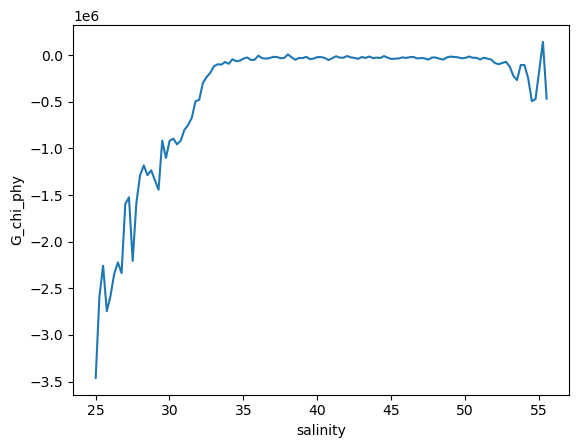

In [39]:
farther_away.isel(salinity=slice(50,-1)).mean(dim=['nCells','Time']).plot()

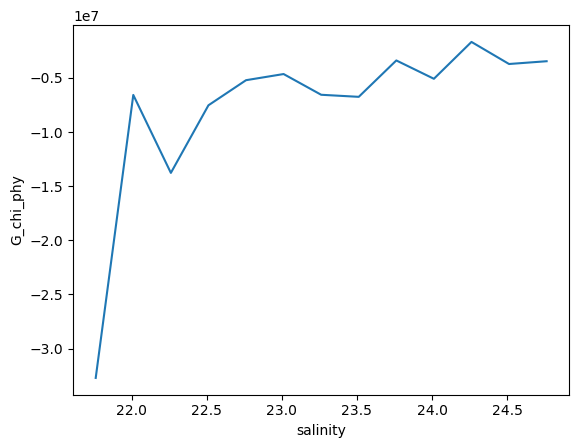

In [40]:
farther_away.isel(salinity=slice(0,50)).mean(dim=['nCells','Time']).plot()

In [41]:
G_chi_phy_isel, cumsum_G_chi_phy_isel = vertical_cumsum(G_phy_comp_ds, 'G_chi_phy', 'isel', time_idx)

reduced time dimension by  isel
time_idx =  115


In [42]:
maxima_indices, minima_indices = find_min_max_idx(G_chi_phy_avg.values)
max_G_chi_phy_avg = G_chi_phy_avg.salinity.isel(salinity=maxima_indices)
min_G_chi_phy_avg = G_chi_phy_avg.salinity.isel(salinity=minima_indices)

maxima at  [-1.24599533e+08 -3.06625085e+08 -9.52673256e+06 -1.30662789e+07
 -1.62546147e+07]
minima at  [-3.30449980e+08 -3.38442330e+08 -3.67288297e+08 -1.49088926e+07
 -1.70617792e+07 -6.30900554e+07]


## Tentative $\mathcal{G}^{\text{(phy)}}$ plots 

### Interpretation
>- We have define our water mass to be all waters with $\lambda \ge \tilde\lambda$
>- This means we should integrate (cumsum) from our greatest salinity values to our lowest.
>- By the time we reach $\tilde\lambda = \tilde\lambda_{freshest}$, then the entire water column will be accounted for.
>- $\mathcal{M}_{\ge}$ increases in size when "its mass transfports are net convergent and therefore increase the size of $\mathcal{M}_\ge$ defined to have salinity values greater than the threshold $\tilde\lambda$."
>>- This is based on the definition of WMT from Drake et al., 2025.
>>- This would mean that **positive** values of $\mathcal{G}^{\text{(phy)}}$ **increase salinity** (fresh water gets mixed into a saltier density class $\mathcal{M}_\ge$)
>>- And **negative** values of $\mathcal{G}^{\text{(phy)}}$ **decrease salinity** (salty water gets mixed OUT of $\mathcal{M}_\ge$)

----
6/26/26

Interpretation after a more scientifically sound way of remapping (average over time last)
>- Made this calculation more scientifically sound, but idk what these figures mean anymore. 
>- Genuinely, I don't get this for a couple reasons.
1. How is it possible that for nearly all salinity classes, $\mathcal{G}^{\text{(phy)}}_\mathcal{F}$ is less than 0?
>- Physically, I have no clue what this means. All water is getting saltier? Idk how water can mix and only get saltier, shouldn't the freshwater cause the salty water to get fresher? Why don't we see this?
>- Why is the cumulative sum almost nearly monotonically increasing? Again, wouldn't this point to more transformation in only one direction?

2. Does this mean that to get the budget to close numerical mixing is negative/acts in the opposite direction? That just doesn't make any sense to me.
>- I just find it very hard to believe that physical mixing only acts in one direction, and nuemrical mixing acts in the other?

3. But I genuinely thought that all my calculations up until this point have been much more careful with remapping to cell centers and averaging after the remap? 


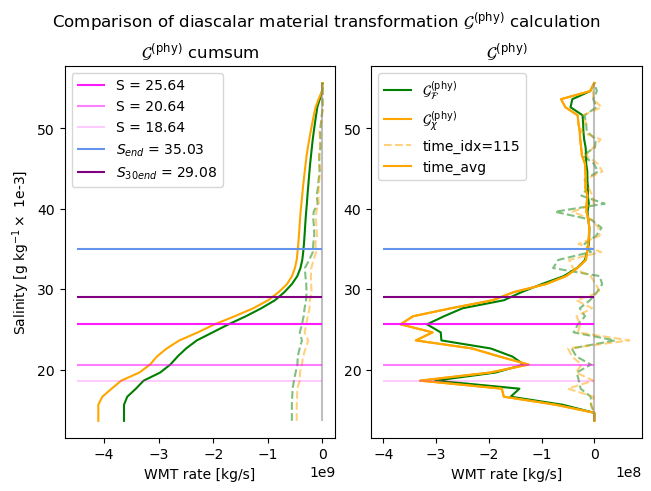

In [43]:
# comparison of G_F_phy and G_chi_phy on salinity coordinates
fig, ax = plt.subplots(nrows=1, ncols=2, constrained_layout=True)

y_values = G_phy_comp_ds.salinity
# plot the time averaged G_F_phy and G_chi_phy cumsums
ax[0].plot(cumsum_G_F_phy_avg, y_values, color='green')
ax[0].plot(cumsum_G_chi_phy_avg, y_values, color='orange')

# plot for a specific time
ax[0].plot(cumsum_G_F_phy_isel, y_values, color='green', alpha=0.5, linestyle='dashed')
ax[0].plot(cumsum_G_chi_phy_isel, y_values, color='orange', alpha=0.5, linestyle='dashed')

# plot the time averaged G_F_phy and G_chi_phy
ax[1].plot(G_F_phy_avg, y_values, color='green',label=r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
ax[1].plot(G_chi_phy_avg, y_values, color='orange',label=r'$\mathcal{G}_\chi^{\text{(phy)}}$')

# plot for a specific time
ax[1].plot(G_F_phy_isel, y_values, color='green', alpha=0.5, linestyle='dashed')
ax[1].plot(G_chi_phy_isel, y_values, color='orange', alpha=0.5, linestyle='dashed',label='time_idx=' + str(time_idx))

# just to get something on the legend
ax[1].plot(G_chi_phy_avg, y_values, color='orange',label='time_avg')

ax[1].legend()

# format
ax[0].vlines(0,ymin=y_values[0], ymax = y_values[-1], color='gray', alpha=0.5)
ax[1].vlines(0,ymin=y_values[0], ymax =y_values[-1], color='gray', alpha=0.5)

fig.suptitle(r'Comparison of diascalar material transformation $\mathcal{G}^{\text{(phy)}}$ calculation')

ax[0].set_xlabel('WMT rate [kg/s]')
ax[1].set_xlabel('WMT rate [kg/s]')

ax[0].set_title(r'$\mathcal{G}^{\text{(phy)}}$ cumsum')
ax[1].set_title(r'$\mathcal{G}^{\text{(phy)}}$')

ax[0].set_ylabel(r'Salinity [g kg$^{-1} \times$ 1e-3]')

# plot the maxima
# for i in np.arange(0,len(max_G_chi_phy_avg)):
#     ax[1].hlines(max_G_chi_phy_avg[i], xmin=-4e8, xmax=0, alpha = (i+1)/10, color='magenta')

# # plot the minima
# for i in np.arange(0,len(min_G_chi_phy_avg)):
#     ax[1].hlines(min_G_chi_phy_avg[i], xmin=-4e8, xmax=0, alpha = (i+1)/10, color='blue')

# plot the "relevant" minima and maxima

ax[0].hlines(min_G_chi_phy_avg[2], xmin=-4.5e9, xmax=0, color = 'magenta', alpha=0.9, label='S = '+ str(np.round(min_G_chi_phy_avg[2].values,decimals=2)))
ax[1].hlines(min_G_chi_phy_avg[2], xmin=-4e8, xmax=0, color = 'magenta', alpha=0.9, label='S = '+ str(np.round(min_G_chi_phy_avg[2].values,decimals=2)))

ax[0].hlines(max_G_chi_phy_avg[0], xmin=-4.5e9, xmax=0, color = 'magenta', alpha=0.5, label='S = '+ str(np.round(max_G_chi_phy_avg[0].values,decimals=2)))
ax[1].hlines(max_G_chi_phy_avg[0], xmin=-4e8, xmax=0, color = 'magenta', alpha=0.5, label='S = '+ str(np.round(max_G_chi_phy_avg[0].values,decimals=2)))

ax[0].hlines(min_G_chi_phy_avg[0], xmin=-4.5e9, xmax=0, color = 'magenta', alpha=0.2, label='S = '+ str(np.round(min_G_chi_phy_avg[0].values,decimals=2)))
ax[1].hlines(min_G_chi_phy_avg[0], xmin=-4e8, xmax=0, color = 'magenta', alpha=0.2, label='S = '+ str(np.round(min_G_chi_phy_avg[0].values,decimals=2)))


# plot the end salinity
end_salinity = ds_output.salinity.isel(Time=-1).mean()
ax[0].hlines(end_salinity, xmin=-4.5e9, xmax=0, color = 'cornflowerblue', label=r'$S_{end}$ = '+ str(np.round(end_salinity.values,decimals=2)))
ax[1].hlines(end_salinity, xmin=-4e8, xmax=0, color = 'cornflowerblue', label=r'$S_{end}$ = '+ str(np.round(end_salinity.values,decimals=2)))

# most of the mixing occurs in the upper 35 levels, plot the mean salinity of the freshest 35 levels
end_30_salinity = ds_output.salinity.isel(nVertLevels=slice(0,30), Time = -1).mean()
ax[0].hlines(end_30_salinity, xmin=-4.5e9, xmax=0, color = 'purple', label=r'$S_{30end}$ = '+ str(np.round(end_30_salinity.values,decimals=2)))
ax[1].hlines(end_30_salinity, xmin=-4e8, xmax=0, color = 'purple', label=r'$S_{30end}$ = '+ str(np.round(end_30_salinity.values,decimals=2)))

ax[0].legend()

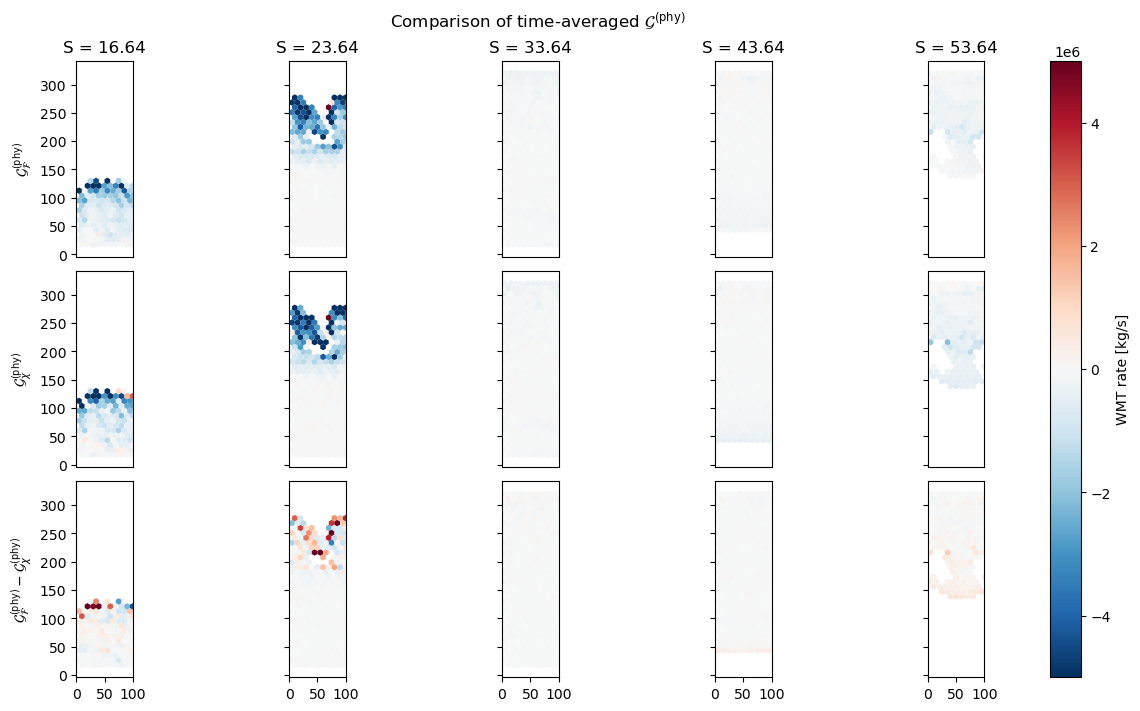

In [44]:
# comparison of G_F_phy and G_chi_phy on salinity surfaces
fig, ax = plt.subplots(nrows=3, ncols=5, constrained_layout=True, figsize=(12,7))

G_phy_comp_ds['diff'] = G_phy_comp_ds.G_F_phy_center - G_phy_comp_ds.G_chi_phy

isosurface_idx = np.array([3,10,20,30,40]) 
row_variables = ['G_F_phy_center' ,'G_chi_phy', 'diff']

for i in range(0,3):
    for j in range(0,5):
        c = mosaic.polypcolor(ax[i,j], descriptor, G_phy_comp_ds[row_variables[i]].isel(salinity = isosurface_idx[j]).mean(dim='Time'), 
                          cmap = 'RdBu_r', vmin= -5e6, vmax = 5e6)

# format
for i in range(0,3):
    for j in range(0,5):
        ax[i,j].set_yticklabels([])
        ax[i,j].set_xticks([])
        ax[i,j].set_aspect(1.0)
        ax[0,j].set_title(f'S = {np.round(G_phy_comp_ds.salinity[isosurface_idx[j]].values,decimals=2)}')
        ax[2,j].set_xticks(np.arange(0,150000,50000))
        ax[2,j].set_xticklabels(np.arange(0,150,50).astype(str))

# y axes
ax[0,0].set_yticks(np.arange(0,350000,50000))
ax[0,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[0,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')

ax[1,0].set_yticks(np.arange(0,350000,50000))
ax[1,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[1,0].set_ylabel(r'$\mathcal{G}_\chi^{\text{(phy)}}$')

ax[2,0].set_yticks(np.arange(0,350000,50000))
ax[2,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[2,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}} - \mathcal{G}_\chi^{\text{(phy)}}$')

fig.colorbar(c, ax=ax, label = 'WMT rate [kg/s]')
fig.suptitle(r'Comparison of time-averaged $\mathcal{G}^{\text{(phy)}}$');

## A brief attempt at interpretation
6/29/26

*I really am not convinced that my calculation is correct because I don't understand how $\mathcal{G}^\text{(phy)}$ is positive for all salinity classes. Unless my target coordinates have a $\Delta \tilde\lambda$ that is too large, which I will have to check.*

Regardless, I will attempt some amount of interpretation.

Note that $diff = \mathcal{G}_\mathcal{F}^{\text{(phy)}} - \mathcal{G}_\chi^{\text{(phy)}}$. This means that 
- RED:  $ diff > 0 \implies \mathcal{G}_\mathcal{F}^{\text{(phy)}} > \mathcal{G}_\chi^{\text{(phy)}} \implies$ convergence of a diffusive flux calculatesm ore physical mixing. 
- BLUE: $ diff < 0 \implies \mathcal{G}_\mathcal{F}^{\text{(phy)}} < \mathcal{G}_\chi^{\text{(phy)}} \implies$ DVD calculates more vertical physical mixing.

*How is `tracerVertMixTendency` actually calculated?*

In the time average, it appears that $\mathcal{G}_\chi^{\text{(phy)}}$ calculates more transformation via mixing than $\mathcal{G}_\mathcal{F}^{\text{(phy)}}$, particularly in the salinity range of 25-30 g/kg x 1e-3. Notably, this salinity range is where the greatest amount of transformation occurs (we all see that hte cumsum graph has the sharpest increase in this range). 
- Our initial salinity conditions have that salinity linearly incraeses away from the base of the channel (cross-channel dist = 0) such that all S is in the range [15,55]
- The equation of state is linear.
- So would we expect linear mixing too?
- In which case, I'm not following why the greatest amount of mixing is occurring in the 20-30 g/kg x 1e-3 range rather than at $\sim$35, which would be the value of linear mixing?
- Maybe temperature has an effect on density and subsequent mixing?

Next steps:
- The last 2 cells show that the surface salinity transformation $\mathcal{S}$ and the salinty tendency $\partial_t S$ both equal 0 (assuming e-7 is close to machine precision or zero??)
- Which means you should be able to calculate the budget, which requires just the $\mathcal{G}$ terms in the budget.
- Since $\mathcal{M}_\ge$ is defined only by $\lambda \ge \tilde \lambda$ isosurfaces and not some geographic region, then there is no $\Psi$ term.

------------
6/30/26

After correcting for $\Delta \lambda = \lambda_i - \lambda_{i+1}$, we end up with $\mathcal{G}^{\text{(phy)}} < 0$ for all salinity classes in the time average. 

I will first explain the general interpretation of the plots. Then I will explain the plots in the context of the data. 
### Background
>- We define $\mathcal{M}_\ge$ s.t. $\lambda \ge \tilde\lambda$. This means to capture *ALL* water in the domain, $\lambda \to 0$ (i.e., $\lambda$ gets smaller and smaller).
>- This means that when we calculate $\mathcal{G}^{\text{(phy)}}$, which requires taking the derivative $\partial_\lambda \mathcal{G}^{\text{(phy)}}$, we are looking at $\lambda \to 0$, rather than the traditional $\lambda \to \infty$
>- The discretized version is then
-
$$
\begin{equation}
    \frac{\partial \mathcal{G}^{\text{(phy)}}}{\partial \lambda} \approx \frac{\mathcal{G}^{\text{(phy)}}_i - \mathcal{G}^{\text{(phy)}}_{i+1}}{\lambda_i - \lambda_{i+1}}
\end{equation}
$$
>- where $\lambda_i < \lambda_{i+1} \implies \lambda_i - \lambda_{i+1} < 0 \, \forall i$
>- This means that when reading a plot of salinity (y-axis) vs WMT transformation (ie., $\mathcal{G}^{\text{(phy)}}$) (x-axis) where the origin is fresh water, we read from bottom to top.

### Interpretation of $\mathcal{G}^\text{(phy)}$
>- A **positive** $\mathcal{G}^{\text{(phy)}} \implies $ **salinifying**
> >- There is a an **addition** of mass into $\mathcal{M}_\ge$. Fresh water is getting saltier. Water is added to the salty water mass $\mathcal{M}_\ge$.
>- A **negative** $\mathcal{G}^{\text{(phy)}} \implies$ **freshening**
> >- There is a **removal** of mass from $\mathcal{M}_\ge$. Salty water is getting fresher. Water is removed from the salty water mass $\mathcal{M}_\ge$.

### Interpretation of $\partial_\lambda \mathcal{G}^{\text{(phy)}}$
>- Recall we are reading the graph from fresh water (low $\lambda$; $\lambda_i$) to salty water (large $\lambda$; $\lambda_{i+1}$.
>- Again, this comes from the fact that we are "integrating" or taking the derivative where $\lambda \to 0$, rather than $\lambda \to \infty$ based on how we defined $\mathcal{M}_\ge$, rather than $\mathcal{M}_\le$.
>- A **positive** $\partial_\lambda \mathcal{G}^{\text{(phy)}} \implies \mathcal{G}^{\text{(phy)}}_{i+1} > \mathcal{G}^{\text{(phy)}}_i$
> >- The mass flux of water from the $\lambda_{i-1/2}$ salinity class into the $\tilde\lambda_i$ salinity class is *less than* the mass flux of water from the $\tilde\lambda_i$ isalinity class into the $\lambda_{i+1/2}$ salinity class.
> >- There is a *divergence* of mass flux, and the parcel $\mathcal{M}_\ge$ is getting **smaller**.
>- A **negative** $\partial_\lambda \mathcal{G}^{\text{(phy)}} \implies \mathcal{G}^{\text{(phy)}}_{i+1} < \mathcal{G}^{\text{(phy)}}_i$
> >- The mass flux of water from $\lambda_{i-1/2}$ salinity class into the $\tilde\lambda_i$ salinity class is *greater than* the mass flux of water from the $\tilde\lambda_i$ salinity class into the $\lambda_{i+1/2}$ salinity class.
> >- There is a *convergence* of mass flux, and the parcel $\mathcal{M}_\ge$ is getting **larger**.
>- A **zero** $\partial_\lambda \mathcal{G}^{\text{(phy)}} \implies \mathcal{G}^{\text{(phy)}}_{i+1} = \mathcal{G}^{\text{(phy)}}_i$
> >- The mass flux of water from $\lambda_{i-1/2}$ salinity class into the $\tilde\lambda$ salinity class is *exactly equal to* the mass flux of water from the $\tilde\lambda_i$ salinity class into the $\lambda_{i+1/2}$ salinity class.
> >- The parcel $\mathcal{M}_\ge$ does not change in size.
> >- This is what a relative maximum or minimum in these graphs means.
> >

### Interpretation of $\mathcal{G}^{\text{(phy)}}$ plotted wrt salinity class
Analyze the plots from bottom (freshest) to top (saltiest). 
>- We note that in the time-average, $\mathcal{G}^{\text{(phy)}} < 0$ for all salinity classes.
> >- This generally suggests an overall freshening in the domain. A time series of the domain-averaged salinity shows that as the simulation runs, the salinity decreases.
> >- *However*, I do not understand why there is a freshening of the freshest water. That water should, in general, be getting mixed to be saltier. This makes me wonder if my $\Delta \lambda$ choice is too large.
>- There is a relative minima at $S=18.636$ where $\partial_\lambda \mathcal{G}^{\text{(phy)}}$ switches from negative to positive.
> >- For water fresher than 18.636 x 1e-3 g/kg, the water parcel is getting larger, but for water saltier than 18.636 x 1e-3 g/kg, the water parcel is getting smaller.
> >- This suggests mixing of saltier water to fresher water?
>- There is a relative maxima at $S=20.636$ where $\partial_\lambda \mathcal{G}^{\text{(phy)}}$ switches from positive to negative.
> >- For water fresher than 20.636 x 1e-3 g/kg, the water parcel is getting smaller, but for water saltier than 20.636 x 1e-3 g/kg, the water parcel is getting larger.
> >- This suggests fresh water is mixing to salty water?
>- There is a relative minima at $S=25.636$ where $\partial_\lambda \mathcal{G}^{\text{(phy)}}$ switches from negative to positive.
> >- For water fresher than 25.636 x 1e-3 g/kg, th water parcel is getting larger, but for water saltier than 25.636 x 1e-3 g/kg, the water parcel is getting smaller.
> >- This suggests fresh water is mixing into salty water? The salty water parcel is getting smaller. 

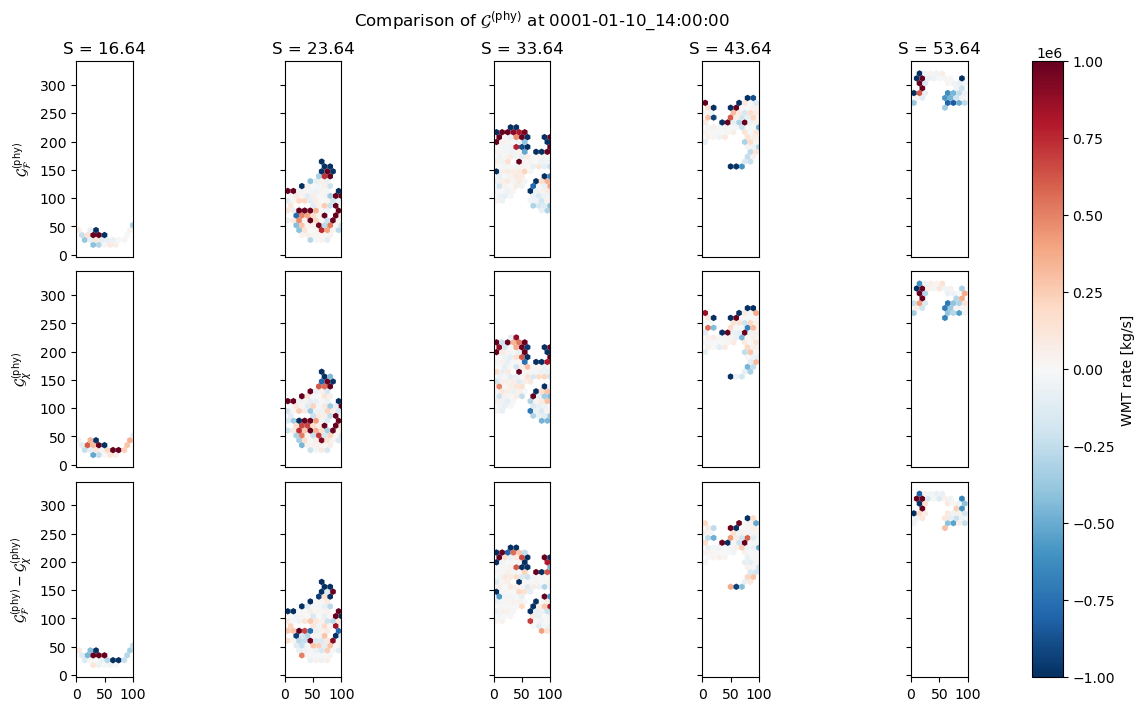

In [45]:
# comparison of G_F_phy and G_chi_phy on salinity surfaces
fig, ax = plt.subplots(nrows=3, ncols=5, constrained_layout=True, figsize=(12,7))

G_phy_comp_ds['diff'] = G_phy_comp_ds.G_F_phy_center - G_phy_comp_ds.G_chi_phy

isosurface_idx = np.array([3,10,20,30,40]) 
row_variables = ['G_F_phy_center' ,'G_chi_phy', 'diff']

for i in range(0,3):
    for j in range(0,5):
        c = mosaic.polypcolor(ax[i,j], descriptor, G_phy_comp_ds[row_variables[i]].isel(salinity = isosurface_idx[j], Time = time_idx), 
                          cmap = 'RdBu_r', vmin= -1e6, vmax = 1e6)

# format
for i in range(0,3):
    for j in range(0,5):
        ax[i,j].set_yticklabels([])
        ax[i,j].set_xticks([])
        ax[i,j].set_aspect(1.0)
        ax[0,j].set_title(f'S = {np.round(G_phy_comp_ds.salinity[isosurface_idx[j]].values,decimals=2)}')
        ax[2,j].set_xticks(np.arange(0,150000,50000))
        ax[2,j].set_xticklabels(np.arange(0,150,50).astype(str))

# y axes
ax[0,0].set_yticks(np.arange(0,350000,50000))
ax[0,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[0,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')

ax[1,0].set_yticks(np.arange(0,350000,50000))
ax[1,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[1,0].set_ylabel(r'$\mathcal{G}_\chi^{\text{(phy)}}$')

ax[2,0].set_yticks(np.arange(0,350000,50000))
ax[2,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[2,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}} - \mathcal{G}_\chi^{\text{(phy)}}$')

fig.colorbar(c, ax=ax, label = 'WMT rate [kg/s]')
fig.suptitle(r'Comparison of $\mathcal{G}^{\text{(phy)}}$ at ' + str(ds_output.xtime.isel(Time=time_idx).values.item().decode('utf-8')));

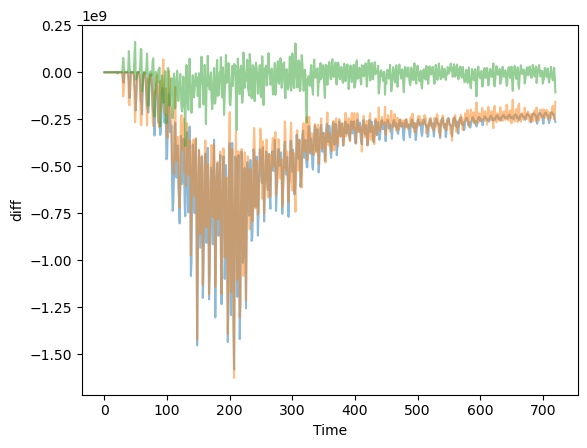

In [46]:
G_phy_comp_ds.G_F_phy_center.sum(dim=['nCells','salinity']).plot(alpha=0.5)
G_phy_comp_ds.G_chi_phy.sum(dim=['nCells','salinity']).plot(alpha=0.5)
G_phy_comp_ds['diff'].sum(dim=['nCells','salinity']).plot(alpha=0.5)

In [47]:
G_phy_comp_ds.G_chi_phy.sum()

<xarray.DataArray 'G_chi_phy' ()> Size: 8B
array(-2.42384129e+11)

In [48]:
G_phy_comp_ds.G_F_phy_center.sum()

<xarray.DataArray 'G_F_phy_center' ()> Size: 8B
array(-2.59688949e+11)

In [49]:
ds_output.salinityTend.sum()

<xarray.DataArray 'salinityTend' ()> Size: 4B
array(-1.2665987e-07, dtype=float32)

In [50]:
ds_output.salinitySurfaceFluxTendency.sum()

<xarray.DataArray 'salinitySurfaceFluxTendency' ()> Size: 4B
array(0., dtype=float32)

In [51]:
ds_output.salinity.isel(Time=0).mean()

<xarray.DataArray 'salinity' ()> Size: 8B
array(35.00279236)

In [52]:
ds_output.salinity.isel(Time=-1).mean()

<xarray.DataArray 'salinity' ()> Size: 8B
array(35.0254364)

In [53]:
G_F_phy_avg

<xarray.DataArray 'G_F_phy_center' (salinity: 43)> Size: 344B
array([ 0.00000000e+00,  0.00000000e+00, -5.98698593e+07, -1.58557585e+08,
       -1.41938357e+08, -3.01356694e+08, -1.87588397e+08, -1.33347721e+08,
       -1.55507727e+08, -1.96379217e+08, -2.89938354e+08, -2.91175067e+08,
       -3.17199564e+08, -2.85139201e+08, -2.49671810e+08, -1.71171709e+08,
       -1.38104404e+08, -9.97115245e+07, -5.77860792e+07, -3.28644309e+07,
       -1.76813091e+07, -1.35831916e+07, -1.03248412e+07, -9.57843041e+06,
       -9.34483037e+06, -1.12895535e+07, -1.27575937e+07, -1.03257540e+07,
       -1.21868209e+07, -1.19493941e+07, -1.31005225e+07, -1.31511606e+07,
       -1.53653343e+07, -1.55299274e+07, -1.63911687e+07, -1.92090227e+07,
       -2.06176941e+07, -2.11396325e+07, -2.21664577e+07, -4.50565417e+07,
       -4.15912804e+07, -7.67392665e+06,  0.00000000e+00])
Coordinates:
  * salinity  (salinity) float64 344B 13.64 14.64 15.64 ... 53.64 54.64 55.64

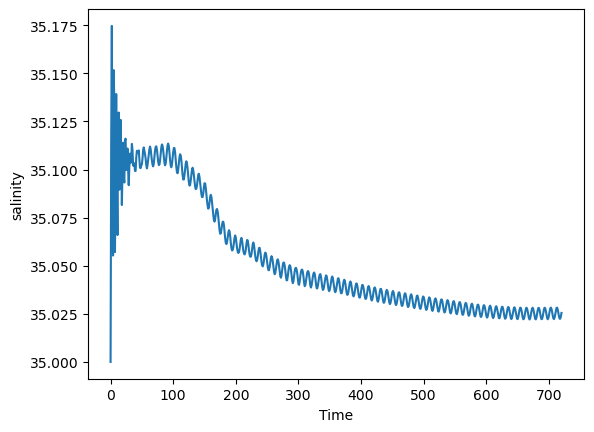

In [54]:
salinity_ts = ds_output.salinity.mean(dim=['nCells','nVertLevels'])
salinity_ts.plot()

In [56]:
# 7/1/26 Why is G_F_phy vs salinity always negative for all salinity classes?

# look at the og salinity vertical mixing tendency, remap that to salinity, look at the sign
ds_check = ds_output.salinityVertMixTendency.mean(dim=['Time','nCells'])

# interpolate the DVD vertical physical mixing onto nVertLevels
grid_check = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                        periodic = False, 
                        autoparse_metadata=False)

ds_check = ds_output
ds_check['salinity_P1'] = grid_check.interp(ds_check.salinity, 'Z', boundary = 'extend')

# remap from nVertLevels coords to salinity coords
ds_F_transformed = grid_check.transform(ds_check.salinityVertMixTendency,
                                        'Z',
                                        ds_check['salinity'].mean(dim=['nCells','Time']), # target coordinates in salinity that allow remapping to salinity
                                        method= 'linear',
                                        target_data = ds_check.salinity)
# rename the nVertLevelsP1 to salinity
ds_F_transformed = ds_F_transformed.rename({'nVertLevels' : 'salinity'}).to_dataset(name='salinityVertMixTendency')

# transform temperature in salinity coordinates
ds_T_transformed = grid_check.transform(ds_check.temperature,
                                        'Z',
                                        ds_check['salinity'].mean(dim=['nCells','Time']), # target coordinates in salinity that allow remapping to salinity
                                        method= 'linear',
                                        target_data = ds_check.salinity)
ds_T_transformed = ds_T_transformed.rename({'nVertLevels' : 'salinity'}).to_dataset(name='Temperature')

# transform chi_num_salinity into salnity coordinates
ds_chi_num_transformed = grid_check.transform(ds_check.chiSpurSaltBR08,
                                              'Z',
                                              ds_check['salinity'].mean(dim=['nCells','Time']), # target coordinates in salinity that allow for remapping to center salinity
                                              method = 'linear',
                                              target_data = ds_check.salinity)
ds_chi_num_transformed = ds_chi_num_transformed.rename({'nVertLevels' : 'salinity'}).to_dataset(name='chi_num_salt')

ds_chi_phy_transformed = grid_check.transform(grid_check.interp(ds_check.chiPhyVerSalt, 'Z', boundary='extend'),
                                              'Z',
                                              ds_check['salinity'].mean(dim=['nCells','Time']), # target coordinates in salinity that allow for remapping to center salinity
                                              method = 'linear',
                                              target_data = ds_check.salinity)
ds_chi_phy_transformed = ds_chi_phy_transformed.rename({'nVertLevels' : 'salinity'}).to_dataset(name='chi_phy_salt')

/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: divide by zero encountered in _interp_1d_linear
  return self.ufunc(*args, **kwargs)
/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: invalid value encountered in _interp_1d_linear
  return self.ufunc(*args, **kwargs)
/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: divide by zero encountered in _interp_1d_linear
  return self.ufunc(*args, **kwargs)
/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: invalid value encountered in _interp_1d_linear
  return self.ufunc(*args, **kwargs)
/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: divide by zero encountered in _interp_1d_linear
  return self.ufunc

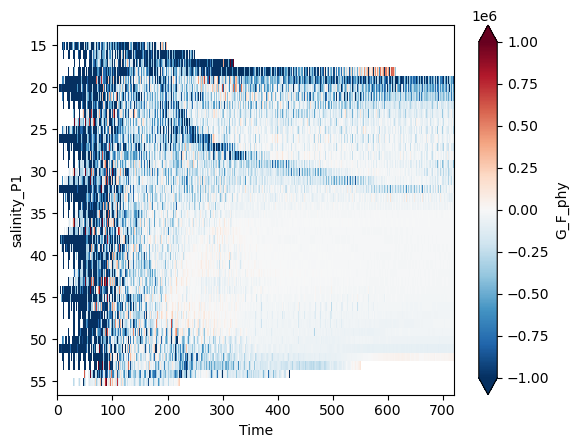

In [57]:
G_phy_comp_ds.G_F_phy.mean(dim='nCells').plot(y='salinity_P1',vmin=-1e6, vmax=1e6, cmap='RdBu_r')
plt.gca().invert_yaxis()

In [ ]:
G_phy_comp_ds.G_F_phy.sum(dim='nCells').plot(y='salinity_P1',cmap='RdBu_r',vmin=-5e7,vmax=5e7)
plt.gca().invert_yaxis()

In [ ]:
ds_F_transformed.salinityVertMixTendency.mean(dim='nCells').plot(y='salinity',vmin=-5e-6, vmax=5e-6, cmap='RdBu_r')
plt.gca().invert_yaxis()

In [ ]:
ds_T_transformed.Temperature.mean(dim='nCells').plot(y='salinity', cmap = cmo.thermal,vmin=23,vmax=23.5)
plt.gca().invert_yaxis()

In [ ]:
fig, ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)
ds_output.salinityVertMixTendency.mean(dim='nCells').plot(y='nVertLevels',vmin=-5e-6, vmax=5e-6,cmap='RdBu_r', add_colorbar=True)
ds_output.salinity.mean(dim='nCells').plot.contour(y='nVertLevels',levels=ds_F_transformed.salinity[::3],add_colorbar=True, cmap = cmo.haline_r)
ax.invert_yaxis()

In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)
ds_dvd.chiSpurSaltBR08.mean(dim='nCells').plot(y='nVertLevels', vmin=-4e-5, vmax=4e-5,cmap='RdBu_r')
ds_output.salinity.mean(dim='nCells').plot.contour(y='nVertLevels',levels=ds_F_transformed.salinity[::3],add_colorbar=True, cmap = cmo.haline_r)
ax.invert_yaxis()

In [ ]:
ds_chi_phy_transformed.chi_phy_salt.mean(dim='nCells').plot(y='salinity',vmin=-5e-6, vmax=5e-6, cmap='RdBu_r')
plt.gca().invert_yaxis()

In [ ]:
ds_chi_num_transformed.chi_num_salt.mean(dim='nCells').plot(y='salinity',vmin=-5e-6, vmax=5e-6, cmap='RdBu_r')
plt.gca().invert_yaxis()